# 导包 读取数据

In [1]:
# 导包
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['SimHei']       # 指定中文字体

# 从指定的数据源中读取房屋数据
data = pd.read_csv(r"D:\AAAjobbing\actfirst\Numpy&Pandas\data\house_sales.csv")
data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long
0,1,2005-10-24,476315.91,8,4,1921,1856,3,0,0,3,7,1864,87,1979,2010,98001,47.341860,-122.183176
1,2,1937-07-18,698980.64,4,4,1503,6659,2,0,1,1,7,2177,100,1937,0,98010,47.532967,-122.026116
2,3,2008-08-01,663024.75,3,3,3494,3112,2,0,3,4,12,2030,1084,1968,1989,98006,47.345444,-121.635418
3,4,2011-08-31,629698.77,8,1,2618,8264,1,0,2,4,7,1576,1108,1911,1999,98010,47.749573,-121.794627
4,5,2011-02-26,658139.54,1,2,1661,3386,1,0,3,3,2,517,816,1900,0,98001,47.737984,-121.701806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,1953-07-11,303685.99,3,2,2378,6259,1,0,4,4,13,2398,450,1927,1992,98010,47.394280,-121.689675
9996,9997,2016-01-03,336882.94,2,1,4837,6226,2,1,2,1,8,2198,1567,1986,2006,98003,47.530260,-122.444554
9997,9998,2021-11-12,423961.29,4,4,4750,1641,2,1,1,2,1,2442,380,2018,0,98004,47.020433,-122.275511
9998,9999,1969-09-03,394782.02,6,5,4108,7847,1,0,4,3,1,4226,1899,1912,0,98001,47.034089,-122.122351


# 数据清洗

In [5]:
# 过滤缺失值
data = data.dropna()

# 检测异常值 使用IQR方法
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1
low_bound = Q1 - 1.5 * IQR
high_bound = Q3 + 1.5 * IQR
data = data[(low_bound <= data['price']) & (data['price'] <= high_bound)]
data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long
0,1,2005-10-24,476315.91,8,4,1921,1856,3,0,0,3,7,1864,87,1979,2010,98001,47.341860,-122.183176
1,2,1937-07-18,698980.64,4,4,1503,6659,2,0,1,1,7,2177,100,1937,0,98010,47.532967,-122.026116
2,3,2008-08-01,663024.75,3,3,3494,3112,2,0,3,4,12,2030,1084,1968,1989,98006,47.345444,-121.635418
3,4,2011-08-31,629698.77,8,1,2618,8264,1,0,2,4,7,1576,1108,1911,1999,98010,47.749573,-121.794627
4,5,2011-02-26,658139.54,1,2,1661,3386,1,0,3,3,2,517,816,1900,0,98001,47.737984,-121.701806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,1953-07-11,303685.99,3,2,2378,6259,1,0,4,4,13,2398,450,1927,1992,98010,47.394280,-121.689675
9996,9997,2016-01-03,336882.94,2,1,4837,6226,2,1,2,1,8,2198,1567,1986,2006,98003,47.530260,-122.444554
9997,9998,2021-11-12,423961.29,4,4,4750,1641,2,1,1,2,1,2442,380,2018,0,98004,47.020433,-122.275511
9998,9999,1969-09-03,394782.02,6,5,4108,7847,1,0,4,3,1,4226,1899,1912,0,98001,47.034089,-122.122351


# 数据类型转换    将日期字符串转换为日期对象

In [8]:
data['date'] = pd.to_datetime(data['date'])
data.info()

<class 'pandas.DataFrame'>
Index: 9920 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             9920 non-null   int64         
 1   date           9920 non-null   datetime64[us]
 2   price          9920 non-null   float64       
 3   bedrooms       9920 non-null   int64         
 4   bathrooms      9920 non-null   int64         
 5   sqft_living    9920 non-null   int64         
 6   sqft_lot       9920 non-null   int64         
 7   floors         9920 non-null   int64         
 8   waterfront     9920 non-null   int64         
 9   view           9920 non-null   int64         
 10  condition      9920 non-null   int64         
 11  grade          9920 non-null   int64         
 12  sqft_above     9920 non-null   int64         
 13  sqft_basement  9920 non-null   int64         
 14  yr_built       9920 non-null   int64         
 15  yr_renovated   9920 non-null   int64 

# 添加新的特征 房龄,是否翻新

In [11]:
# 添加房龄字段
data['age'] = data['date'].dt.year - data['yr_built']

# 添加是否翻新
data['is_renovated'] = data['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)
data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,age,is_renovated
0,1,2005-10-24,476315.91,8,4,1921,1856,3,0,0,...,7,1864,87,1979,2010,98001,47.341860,-122.183176,26,1
1,2,1937-07-18,698980.64,4,4,1503,6659,2,0,1,...,7,2177,100,1937,0,98010,47.532967,-122.026116,0,0
2,3,2008-08-01,663024.75,3,3,3494,3112,2,0,3,...,12,2030,1084,1968,1989,98006,47.345444,-121.635418,40,1
3,4,2011-08-31,629698.77,8,1,2618,8264,1,0,2,...,7,1576,1108,1911,1999,98010,47.749573,-121.794627,100,1
4,5,2011-02-26,658139.54,1,2,1661,3386,1,0,3,...,2,517,816,1900,0,98001,47.737984,-121.701806,111,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,1953-07-11,303685.99,3,2,2378,6259,1,0,4,...,13,2398,450,1927,1992,98010,47.394280,-121.689675,26,1
9996,9997,2016-01-03,336882.94,2,1,4837,6226,2,1,2,...,8,2198,1567,1986,2006,98003,47.530260,-122.444554,30,1
9997,9998,2021-11-12,423961.29,4,4,4750,1641,2,1,1,...,1,2442,380,2018,0,98004,47.020433,-122.275511,3,0
9998,9999,1969-09-03,394782.02,6,5,4108,7847,1,0,4,...,1,4226,1899,1912,0,98001,47.034089,-122.122351,57,0


# 数值型列描述性统计

In [15]:
# data.describe(include=[np.number])

numeric_columns  = data.select_dtypes(include=[np.number]).columns      # 选择数据集中列
data[numeric_columns].describe()


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,age,is_renovated
count,9920.000000,9920.000000,9920.000000,9920.000000,9920.000000,9920.000000,9920.00000,9920.000000,9920.000000,9920.00000,9920.000000,9920.000000,9920.000000,9920.000000,9920.00000,9920.000000,9920.000000,9920.000000,9920.000000,9920.000000
mean,4999.576815,501176.913458,4.497177,3.521976,2906.252621,5520.140827,1.99879,0.498488,2.016230,2.98619,7.020262,2523.120968,999.640423,1962.190323,589.45625,98005.530141,47.400361,-122.095276,30.834073,0.295766
std,2885.515776,96796.446724,2.297992,1.727336,1210.149117,2603.877734,0.81929,0.500023,1.418711,1.41639,3.745790,1153.197332,576.434433,36.072494,909.73899,2.884177,0.231460,0.289922,27.511698,0.456409
min,1.000000,234347.250000,1.000000,1.000000,801.000000,1000.000000,1.00000,0.000000,0.000000,1.00000,1.000000,500.000000,0.000000,1900.000000,0.00000,98001.000000,47.000216,-122.599943,0.000000,0.000000
25%,2502.750000,433569.022500,2.000000,2.000000,1864.750000,3280.750000,1.00000,0.000000,1.000000,2.00000,4.000000,1527.000000,503.000000,1931.000000,0.00000,98003.000000,47.200907,-122.344484,8.000000,0.000000
50%,4998.500000,501590.870000,4.000000,4.000000,2909.000000,5514.000000,2.00000,0.000000,2.000000,3.00000,7.000000,2526.000000,1002.000000,1962.000000,0.00000,98006.000000,47.399660,-122.091732,23.000000,0.000000
75%,7494.250000,567579.977500,7.000000,5.000000,3957.250000,7802.000000,3.00000,1.000000,3.000000,4.00000,10.000000,3538.000000,1502.000000,1993.000000,1962.00000,98008.000000,47.603961,-121.843167,48.000000,1.000000
max,10000.000000,768558.740000,8.000000,6.000000,5000.000000,10000.000000,3.00000,1.000000,4.000000,5.00000,13.000000,4500.000000,2000.000000,2024.000000,2024.00000,98010.000000,47.799975,-121.600304,124.000000,1.000000


# 数值型列的相关性统计

In [16]:
data[numeric_columns].corr()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,age,is_renovated
id,1.000000,0.010855,-0.006481,-0.008213,0.013453,0.004591,-0.005257,0.003440,0.024962,0.011058,-0.008989,-0.007740,-0.015138,-0.004122,-0.020781,-0.009001,0.003665,-0.001836,-0.005600,-0.020907
price,0.010855,1.000000,0.004781,0.007149,0.010877,0.003869,-0.006972,0.002879,-0.002639,0.001230,0.005664,-0.004094,-0.003577,0.011795,0.000071,0.009807,-0.001027,-0.006395,-0.003221,0.000181
bedrooms,-0.006481,0.004781,1.000000,-0.002854,-0.019688,0.020632,0.018365,-0.004698,0.004235,-0.000585,-0.013480,0.023128,0.009451,0.009989,-0.006625,0.012068,-0.002054,-0.002752,-0.006547,-0.006702
bathrooms,-0.008213,0.007149,-0.002854,1.000000,0.007286,-0.002605,-0.013873,0.005700,-0.002593,0.011600,-0.016328,0.018991,-0.005016,0.005424,0.002826,0.011493,0.000007,0.015834,-0.009277,0.002752
sqft_living,0.013453,0.010877,-0.019688,0.007286,1.000000,0.000902,-0.005671,-0.026665,0.000877,-0.010071,-0.010771,-0.010851,0.026851,0.018162,0.008361,-0.004119,0.001993,-0.001737,-0.005987,0.008283
sqft_lot,0.004591,0.003869,0.020632,-0.002605,0.000902,1.000000,0.011791,0.017277,-0.002371,0.021896,-0.017341,0.009687,0.006931,-0.012749,-0.005783,-0.003489,0.018328,-0.003134,-0.001170,-0.005759
floors,-0.005257,-0.006972,0.018365,-0.013873,-0.005671,0.011791,1.000000,0.031988,-0.012473,0.012062,-0.000288,0.008872,0.008694,0.014884,0.009589,-0.010864,-0.006640,-0.002637,-0.017940,0.009585
waterfront,0.003440,0.002879,-0.004698,0.005700,-0.026665,0.017277,0.031988,1.000000,-0.013680,0.005736,-0.015674,0.005479,0.004332,0.000771,-0.006962,-0.020241,0.009799,-0.001635,0.005398,-0.006875
view,0.024962,-0.002639,0.004235,-0.002593,0.000877,-0.002371,-0.012473,-0.013680,1.000000,0.000914,0.011435,-0.014448,0.010980,-0.015245,-0.002244,0.008196,0.025633,-0.002604,0.006240,-0.002120
condition,0.011058,0.001230,-0.000585,0.011600,-0.010071,0.021896,0.012062,0.005736,0.000914,1.000000,0.004917,0.013942,-0.001390,-0.002543,-0.009872,-0.010967,0.005665,0.009110,0.003242,-0.009588


# 按邮政编码,计算每组的平均房价,平均居住面积,平均卧室数量

In [17]:
data.groupby('zipcode')[['price','sqft_living','bedrooms']].mean()

,price,sqft_living,bedrooms
zipcode,,,
98001,501692.805588,2915.222546,4.356657
98002,497808.793483,2955.262821,4.554487
98003,497924.782782,2872.228953,4.551335
98004,498747.163954,2857.314854,4.407950
98005,503044.206706,2976.320551,4.547689
98006,505899.199081,2888.367677,4.600000
98007,502986.807941,2900.839604,4.356436
98008,499440.801393,2876.627255,4.501002
98009,500330.593340,2901.382627,4.472596


# 按是否翻新分组,计算每组的平均房价,最大居住面积,最小卧室数量
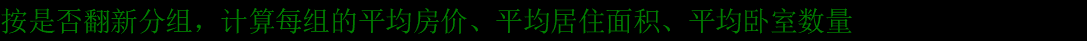

In [18]:
data.groupby('is_renovated').agg({'price':'mean','sqft_living':'max','bedrooms':'min'})

,price,sqft_living,bedrooms
is_renovated,,,
0,501165.589515,5000,1
1,501203.876329,4998,1


# 按房屋使用年限分组(简单分为5个区间)

In [21]:
data['age_group'] = pd.cut(data['age'],5)
data.pivot_table(values=['price','sqft_living','bedrooms'],index='age_group',aggfunc='mean')

,bedrooms,price,sqft_living
age_group,,,
"(-0.124, 24.8]",4.512082,501491.564379,2912.632708
"(24.8, 49.6]",4.487662,501159.032304,2912.831451
"(49.6, 74.4]",4.420180,501706.543912,2867.487906
"(74.4, 99.2]",4.622478,497096.108718,2910.452450
"(99.2, 124.0]",4.358140,503413.042977,2926.920930


# 时间序列分析-每年平均房价

In [22]:
data.groupby(data['date'].dt.year)['price'].mean()

date
1900    488884.680000
1902    513972.100000
1903    509519.793333
1905    522640.340000
1906    470978.868333
            ...      
2020    512492.021111
2021    494507.942625
2022    498970.821277
2023    502406.178047
2024    499999.391169
Name: price, Length: 123, dtype: float64

# 时间序列分析-不同翻新情况平均房价

In [28]:
# data.groupby([data['date'].dt.year,'is_renovated'])['price'].mean()
# data.pivot_table(values='price',index=data['date'].dt.year,columns='is_renovated',aggfunc='mean')
data.pivot_table(values='price',index=[data['date'].dt.year,'is_renovated'],aggfunc='mean')


price
date is_renovated               
1900 0             488884.680000
1902 0             513972.100000
1903 0             445335.310000
     1             637888.760000
1905 0             522640.340000
...                          ...
2022 1             484070.180990
2023 0             502393.039380
     1             502439.298437
2024 0             497149.856014
     1             505383.902403

[240 rows x 1 columns]

# 可视化 房价分布直方图

Text(0, 0.5, '频数')

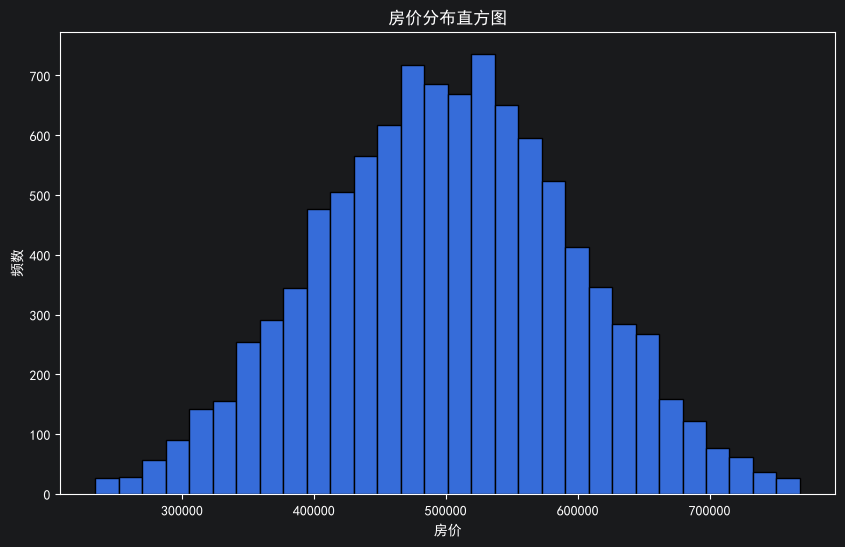

In [29]:
plt.figure(figsize=(10, 6))
plt.hist(data['price'], bins=30, edgecolor='k')
plt.title('房价分布直方图')
plt.xlabel('房价')
plt.ylabel('频数')
